# Creando a ChatGPT desde cero

- Este taller tiene como objetivo enseñar el funcionamiento de los largos modelos del lenguaje (LLM) como ChatGPT mediante la explicación de la arquitectura del Transformer
- Al final del taller entenderás por detrás el funcionamiento de los muy útiles LLMs, e implementarás un modelo capaz de traducir palabras del español al inglés.

In [39]:
import torch
import matplotlib.pyplot as plt
from torch import nn
import numpy as np
import pandas as pd
import torch.nn.functional as F

## ¿Qué es PyTorch?

PyTorch es un framework de **Machine y Deep learning** en Python que permite crear y entrenar modelos de redes neuronales de forma flexible y eficiente, es muy intuitivo para investigación y desarrollo.

Es uno de los estándares de la industria junto con TensorFlow, y es utilizado por empresas como **OpenAI, Tesla, Meta, Amazon**, entre muchas otras.

## Entendiendo que es un tensor
¿Por que PyTorch (y la IA en general) ama los tensores?

Un tensor es una estructura de datos que se utiliza en matemáticas, física e ingeniería para describir propiedades de un sistema. En el contexto de la programación y el aprendizaje automático, un tensor es básicamente un contenedor para datos.

In [40]:
escalar = torch.tensor(7)
escalar, escalar.ndim, escalar.shape

(tensor(7), 0, torch.Size([]))

In [41]:
vector = torch.tensor([7,7])
vector, vector.ndim, vector.shape

(tensor([7, 7]), 1, torch.Size([2]))

In [42]:
matriz = torch.tensor([[7,8],
                      [9,10]])
matriz, matriz.ndim, matriz.shape

(tensor([[ 7,  8],
         [ 9, 10]]),
 2,
 torch.Size([2, 2]))

In [43]:
tensor = torch.tensor([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]]) # Un tensor puede tener 3 o más dimensiones
tensor, tensor.ndim, tensor.shape

(tensor([[[ 1,  2,  3],
          [ 4,  5,  6]],
 
         [[ 7,  8,  9],
          [10, 11, 12]]]),
 3,
 torch.Size([2, 2, 3]))

## torch.rand

Permite crear tensores aleatorios con cualquier shape o forma

- torch.manual_seed es util para algo que se llama reproducibilidad, básicamente permite que los resultados aleatorios siempre sean iguales, de esta forma todos en el taller pueden ver los mismos números al crear estos tensores

In [44]:
torch.manual_seed(42)
random_tensor = torch.rand(3,4) # Crea un tensor (en este caso sería una matriz) con la forma 3 x 4
random_tensor, random_tensor.shape

(tensor([[0.8823, 0.9150, 0.3829, 0.9593],
         [0.3904, 0.6009, 0.2566, 0.7936],
         [0.9408, 0.1332, 0.9346, 0.5936]]),
 torch.Size([3, 4]))

## Funciones de activación
Una función de activación sucede después de hacer una operación entre capas.
- Existen un montón de funciones de activación, entre ellas están:
| Función | Explicación | Enlace |
|---------|-------------|--------|
| ReLU    | Devuelve el mismo número si es positivo y si no devuelve 0 | https://en.wikipedia.org/wiki/Rectified_linear_unit#/media/File:ReLU_and_GELU.svg |
| GeLu | Similar a ReLU pero es diferenciable cuando el valor es 0 | https://en.wikipedia.org/wiki/Rectified_linear_unit#/media/File:ReLU_and_GELU.svg |
| Tanh    | Reduce los valores de -1 a 1 | https://share.google/images/Tkb9ygF8fXENNy1GL |
| Softmax | Convierte los valores a un mapa de probabilidad que suma 1 | https://share.google/images/1PlsT7VCcO2w9yTkM |


In [45]:
torch.manual_seed(42) # Hay que llamar manual_seed cada que uses torch.random
tensor = torch.randn(3,3) # Esto es una distribución normal (promedio ~ 0, desviación estándar ~1)
tensor

tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]])

In [46]:
reLU_tensor = nn.ReLU()(tensor)
print(f'Tensor original: \n {tensor}')
print(f'Tensor ReLU: \n{reLU_tensor}')

Tensor original: 
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]])
Tensor ReLU: 
tensor([[0.3367, 0.1288, 0.2345],
        [0.2303, 0.0000, 0.0000],
        [2.2082, 0.0000, 0.4617]])


In [47]:
geLU_tensor = nn.GELU()(tensor)
print(f'Tensor original: \n {tensor}')
print(f'Tensor GELU: \n{geLU_tensor}')

Tensor original: 
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]])
Tensor GELU: 
tensor([[ 0.2127,  0.0710,  0.1390],
        [ 0.1361, -0.1468, -0.0794],
        [ 2.1781, -0.1670,  0.3129]])


##

In [48]:
tanh_tensor = nn.Tanh()(tensor)
print(f'Tensor original: \n {tensor}')
print(f'Tensor Tanh: \n{tanh_tensor}')

Tensor original: 
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]])
Tensor Tanh: 
tensor([[ 0.3245,  0.1281,  0.2303],
        [ 0.2263, -0.8086, -0.1842],
        [ 0.9761, -0.5635,  0.4314]])


In [49]:
softmax_tensor = nn.Softmax(dim=1)(tensor)
print(f'Tensor original: \n {tensor}')
print(f'Tensor Softmax: \n{softmax_tensor}')
print(f'Suma de softmax: {softmax_tensor.sum(1)}')

Tensor original: 
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]])
Tensor Softmax: 
tensor([[0.3683, 0.2992, 0.3325],
        [0.5215, 0.1348, 0.3438],
        [0.8114, 0.0471, 0.1415]])
Suma de softmax: tensor([1., 1., 1.])


## Operaciones básicas entre tensores

- Multiplicación de matriz
- Traspuesta
- Suma de Tensores
- Multiplicación elemento a elemento
- Reshape

### Multiplicación de matriz

In [50]:
tensor_a = torch.ones(3, 4)
tensor_b = torch.ones(4, 3)
multiplied = torch.matmul(tensor_a, tensor_b) # [3 x 4] x [4 x 3] = [3 x 3]
multiplied, multiplied.shape

(tensor([[4., 4., 4.],
         [4., 4., 4.],
         [4., 4., 4.]]),
 torch.Size([3, 3]))

### Multiplicación uno a uno

In [51]:
tensor_a = torch.full((3, 4), 2)
tensor_b = torch.full((3, 4), 4)
one_by_one_mult = tensor_a * tensor_b
one_by_one_mult, one_by_one_mult.shape

(tensor([[8, 8, 8, 8],
         [8, 8, 8, 8],
         [8, 8, 8, 8]]),
 torch.Size([3, 4]))

### Transpuesta de un tensor

In [52]:
matrix = torch.triu(torch.ones(3, 4))
matrix, matrix.T

(tensor([[1., 1., 1., 1.],
         [0., 1., 1., 1.],
         [0., 0., 1., 1.]]),
 tensor([[1., 0., 0.],
         [1., 1., 0.],
         [1., 1., 1.],
         [1., 1., 1.]]))

In [53]:
tensor = torch.triu(torch.ones(1, 3, 4))
tensor, tensor.transpose(1, 2)

(tensor([[[1., 1., 1., 1.],
          [0., 1., 1., 1.],
          [0., 0., 1., 1.]]]),
 tensor([[[1., 0., 0.],
          [1., 1., 0.],
          [1., 1., 1.],
          [1., 1., 1.]]]))

### Suma de tensores

In [54]:
tensor_a = torch.ones(3, 4)
tensor_b = torch.ones(3, 4)
added = tensor_a + tensor_b
tensor_a, added

(tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]),
 tensor([[2., 2., 2., 2.],
         [2., 2., 2., 2.],
         [2., 2., 2., 2.]]))

### Reshape (Cambio de forma)

In [55]:
tensor = torch.ones(4, 4)
reshaped_tensor = tensor.reshape(1, 2, 8)
tensor, reshaped_tensor

(tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]),
 tensor([[[1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1.]]]))

### Concatenación de Tensores

In [56]:
tensor_a = torch.ones(2, 3)
tensor_b = torch.zeros(2, 3)
concatenated = torch.cat((tensor_a, tensor_b), dim=0)  # concatena por filas
concatenated


tensor([[1., 1., 1.],
        [1., 1., 1.],
        [0., 0., 0.],
        [0., 0., 0.]])

### Reducciones simples

In [57]:
tensor = torch.arange(12).reshape(3, 4).to(dtype=torch.float32)
tensor, tensor.sum(), tensor.mean(), tensor.max(), tensor.min()


(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]),
 tensor(66.),
 tensor(5.5000),
 tensor(11.),
 tensor(0.))

## Términos para entrenar un modelo
| Término | Definición | Enlace |
|---------|------------|--------|
| Train set y Test set | El train set es el conjunto de datos usado para entrenar el modelo, el test set es un conjunto separado, nunca visto durante el entrenamiento, que se usa para evaluar qué tan bien generaliza. | https://blog.roboflow.com/content/images/2020/09/image-14.png |
| Batch Size | La cantidad de ejemplos (muestras de datos) que la red neuronal procesa de una sola vez antes de actualizar los parámetros con backpropagation |https://machinelearningmastery.com/how-to-control-the-speed-and-stability-of-training-neural-networks-with-gradient-descent-batch-size/ |
| Epochs | Una epoch es una pasada completa por todo el dataset. Si tienes 10 000 ejemplos y batch size de 100, una epoch son 100 pasos (batches). | https://media.geeksforgeeks.org/wp-content/uploads/20241024155237307614/epoch-in-machine-learning_.webp |
| Loss function | Métrica que mide qué tan mal o bien está prediciendo el modelo (ej.: MSE, cross-entropy) | https://media.springernature.com/lw1200/springer-static/image/art%3A10.1007%2Fs40745-020-00253-5/MediaObjects/40745_2020_253_Fig3_HTML.png |
| Backpropagation | Algoritmo que te dice hacia donde ir para mejorar el modelo, gracias a que calcula el gradiente (la dirección y magnitud del error) propagando el error desde la salida hasta las capas iniciales. | https://www.youtube.com/watch?v=Ilg3gGewQ5U
| Gradient Descent | Es el método matemático que aplica los gradientes para minimizar la función de pérdida ajustando los parámetros del modelo | [Gradient Descend 3d link](https://share.google/images/S1m70W8MtX2pOh1Uh) [Gradient Descend 2d link](https://share.google/images/JCFXt0cV3avwBKYCi) |
| Optimizer | Algoritmo que actualiza los pesos en base a los gradientes que backpropagation le dé (ej.: SGD, Adam) | |
| Learning Rate (α) | Es un número que define el tamaño del paso al actualizar los pesos en cada evaluación, si es muy pequeño (ej 0.00001) puede que entrenarlo tarde mucho tiempo, si es muy grande (ej. 10), puede que no encuentre el punto de menor pérdida | https://miro.medium.com/v2/resize:fit:1200/0*a2DcKhke63IMowJB.png |
| Parameters | Los números que la red aprende automáticamente durante el entrenamiento (pesos y sesgos). | |
| Hyperparameters | Configuraciones elegidas por ti antes de entrenar. ej.: batch size, épocas, learning rate, número de capas, número de neuronas, tipo de optimizador, entre otros. Estos pueden cambiar drásticamente el comportamiento del modelo, así que hay que configurarlos con cuidado | https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRlVJrFsmTYuuQ1uy1pLSsRbENLRgt9-8o2-g&s |

## Código agnóstico de dispositivo
---
El motivo por el cual la inteligencia artificial ha crecido exponencialmente se debe, además de por las nuevas arquitecturas como el Transformer, sino también el aumento en la capacidad de cómputo, especialmente gracias a las **GPUs (tarjetas gráficas)**. Empresas como **NVIDIA** han hecho posible entrenar grandes modelos de lenguaje de manera eficiente.

Por esta razón, siempre que exista la posibilidad de usar una GPU (por ejemplo, habilitando la opción de GPU en Google Colab), debemos aprovecharla.

¿Qué es CUDA?

- CUDA (Compute Unified Device Architecture) es una plataforma y modelo de programación desarrollados por NVIDIA que permite a los desarrolladores ejecutar operaciones en paralelo usando sus GPUs.

- Gracias a CUDA, los cálculos que serían muy lentos en CPU pueden realizarse de manera masiva en GPU, acelerando el entrenamiento de redes neuronales y otros algoritmos de machine learning.

In [58]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Entendiendo una clásica red neuronal lineal y creandola con numpy

- `y = Wx + b`
Es la forma más básica de una red neuronal. Es muy similar a la función lineal que se ve en cálculo, pero en este caso W, x y b son tensores y no escalares.

Antes de usar `torch.nn.Module`, podemos recrear esta red solo con NumPy, para entender qué está pasando por detrás.

NumPy es una librería optimizada en C/C++, diseñada para trabajar con arreglos multidimensionales y operaciones matemáticas de manera eficiente.

In [59]:
# Capa lineal manual con numpy
class LinearLayerManual:
    def __init__(self, in_features, out_features):
        self.in_features = in_features
        self.out_features = out_features
        self.weights = np.random.random(size=(out_features, in_features))
        self.bias = np.random.random(size=(out_features))

    def forward(self, x):
        # y = xW^T + b
        return np.matmul(x, self.weights.T) + self.bias # [batch_size, in_features] x [in_features, out_features] = [batch_size, out_features]

np.random.seed(42)
manual_layer = LinearLayerManual(in_features=10, out_features=5) # Inicializamos el modelo con pesos aleatorios

np.random.seed(42)
input_tensor = np.random.random(size=(1, 10)) # Batch size de 1 e in_features de 10


output_tensor_manual = manual_layer.forward(input_tensor)
print(f'Tensor inicial: {input_tensor}')
f"Manual Linear Layer Output: {output_tensor_manual}"

Tensor inicial: [[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
  0.05808361 0.86617615 0.60111501 0.70807258]]


'Manual Linear Layer Output: [[4.57294669 3.43645247 2.77410844 3.00219188 2.75575082]]'

## nn.Module

En PyTorch, los modelos se definen como clases que heredan de `torch.nn.Module`.

Esta clase base ya trae funciones útiles como:

- inicializar parámetros,

- definir la arquitectura de la red,

- ejecutar la propagación hacia adelante (forward).

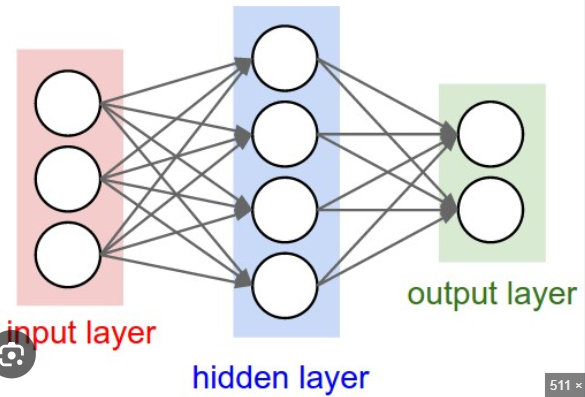

## Modelo en PyTorch

- Vamos a recrear esta red neuronal con capas lineales.
- La hidden layer va a tener como función de activación ReLU y la output una softmax.
- En PyTorch las capas se pueden apilar una encima de otra para hacer cosas más complejas.
- Entre capas pueden haber funciones de activación para mejorar el modelo.

In [60]:
class NeuralNetwork(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(NeuralNetwork, self).__init__()
        self.hidden_layer = nn.Linear(in_features, hidden_features)
        self.output_layer = nn.Linear(hidden_features, out_features)
    def forward(self, x):
        x = self.hidden_layer(x)
        x = torch.relu(x)
        x = self.output_layer(x)
        x = torch.softmax(x, dim = 1)
        return x
    # Esto se puede optimizar apilando todo para no mover los tensores
    # hacia la memoria y luego el procesador 4 veces asi y así evitar
    # pasar varias veces por Python → C.
    # return self.softmax(self.output_layer(self.ReLU(self.hidden_layer)))

## Instanciando el modelo y probándolo con datos "dummy"

In [61]:
model = NeuralNetwork(
    in_features=4,
    hidden_features=4,
    out_features=2)

torch.manual_seed(42)
random_tensor = torch.rand((1, 4))
model

NeuralNetwork(
  (hidden_layer): Linear(in_features=4, out_features=4, bias=True)
  (output_layer): Linear(in_features=4, out_features=2, bias=True)
)

## Entendiendo el state dict

In [62]:
model.state_dict()

OrderedDict([('hidden_layer.weight',
              tensor([[-0.2304, -0.0586, -0.2031,  0.3317],
                      [-0.3947, -0.2305, -0.1412, -0.3006],
                      [ 0.0472, -0.4938,  0.4516, -0.4247],
                      [ 0.3860,  0.0832, -0.1624,  0.3090]])),
             ('hidden_layer.bias',
              tensor([ 0.0779,  0.4040,  0.0547, -0.1577])),
             ('output_layer.weight',
              tensor([[ 0.1343, -0.1356,  0.2104,  0.4464],
                      [ 0.2890, -0.2186,  0.2886,  0.0895]])),
             ('output_layer.bias', tensor([ 0.2539, -0.3048]))])

In [63]:
model.to(device) # Se desplazan los datos al dispositivo (importante para usar CUDA)
resultado = model(random_tensor.to(device))
random_tensor, resultado

(tensor([[0.8823, 0.9150, 0.3829, 0.9593]]),
 tensor([[0.6738, 0.3262]], grad_fn=<SoftmaxBackward0>))

## Definiendo función de pérdida y optimizador

In [64]:
loss_fn = nn.CrossEntropyLoss()
LEARNING_RATE = 0.1
optimizer = torch.optim.SGD(params=model.parameters(), lr = LEARNING_RATE)

## Entrenar el modelo y evaluar resultados

- Vamos a ver como se ve el entrenamiento del modelo, no usaremos un dataset por lo que los datos que entregará el modelo no tendrán sentido pero se podrá ver la idea del training step.
### Situación hipotética
Imagina que vamos a hacer un modelo que pueda distinguir que una palabra existe en un vocabulario.
- Entradas: 4 features
- Salidas: 2 clases (0 = no existe y 1 = si existe)

Como train dataset haremos un tensor aleatorio de shape (1000, 4) que significa que hay 1000 ejemplos, esto es para mostrar la mecánica, en la vida real querrás buscar un dataset real (busca Kaggle, en internet o datos que puedas tener)

Es necesario que el modelo sepa si está bien o no, así que necesitamos los resultados, para eso tendremos las train labels que dirán 0 o 1 a cada uno de los 1000 ejemplos

En deep learning más que el modelo, los datos son lo más importante, así que siempre prioriza tener un dataset lo más general y significativo para el problema que quieras abordar.

En la práctica, antes de entrenar tu red, dedica tiempo a explorar tus datos (visualizar, normalizar, balancear clases). Un buen dataset puede hacer que incluso un modelo sencillo funcione muy bien, mientras que un dataset pobre no servirá aunque uses el modelo más complejo.

In [65]:
train_dataset = torch.rand((1000, 4)) # 1000
train_labels = torch.randint(0, 2, (100,))
train_dataset[:5], train_labels[:5] # Previsualizamos solo 5 elementos

(tensor([[0.3904, 0.6009, 0.2566, 0.7936],
         [0.9408, 0.1332, 0.9346, 0.5936],
         [0.8694, 0.5677, 0.7411, 0.4294],
         [0.8854, 0.5739, 0.2666, 0.6274],
         [0.2696, 0.4414, 0.2969, 0.8317]]),
 tensor([1, 1, 1, 1, 1]))

## Test dataset
También es necesario el test dataset que evaluará que tus predicciones generalizan bien, y así evitamos el overfitting.

In [66]:
test_dataset = torch.rand((100,4))
test_labels = torch.randint(0, 2, (100,))
test_dataset[:5], test_labels[:5]

(tensor([[0.4383, 0.0857, 0.0987, 0.0321],
         [0.5937, 0.3192, 0.2697, 0.9760],
         [0.3477, 0.6686, 0.4120, 0.8015],
         [0.6492, 0.8166, 0.6306, 0.3904],
         [0.9419, 0.4644, 0.2007, 0.6556]]),
 tensor([1, 0, 0, 1, 1]))

## Orden de las operaciones

- Hacemos el forward pass (model(data))
- Calculamos la pérdida (loss function)
- Optimizer zero grad (borra los gradientes acumulados del paso anterior. Si no lo haces, PyTorch acumula los gradientes y el entrenamiento se vuelve incorrecto.)
- loss.backward() (Calcula nuevo gradiente)
- optimizer.step() (Hace backprop y ajusta los parámetros)


In [67]:
EPOCHS = 10000
BATCH_SIZE = 50

## Data loader
PyTorch ofrece una forma mucho más simple para organizar los datos antes de entrenar el modelo, por detrás divide los datos en los batches y tambien permite hacer transformaciones (mas de eso despues), revolver los datos, entre otras cosas muy útiles

In [68]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    list(zip(train_dataset, train_labels)),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    list(zip(test_dataset, test_labels)),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [69]:
from tqdm import tqdm

train_set_loss_per_epoch = []
test_set_loss_per_epoch = []
model.to(device)
for epoch in tqdm(range(EPOCHS)):
    model.train()
    for batch, labels in train_loader:
        batch = batch.to(device) # A CUDA
        labels = labels.to(device) # A CUDA
        predictions = model(batch)
        loss = loss_fn(predictions, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # --- Validation loop ---
    model.eval()
    val_loss = 0
    with torch.no_grad():  # no calculamos gradientes en test
        for batch, labels in test_loader:  # tu loader de validación/test
            batch = batch.to(device)
            labels = labels.to(device)

            predictions = model(batch)
            val_loss += loss_fn(predictions, labels).item()



    if epoch % 100 == 0:
      train_set_loss_per_epoch.append(loss.item())
      test_set_loss_per_epoch.append(val_loss)


100%|██████████| 10000/10000 [00:26<00:00, 370.53it/s]


## Plot the data

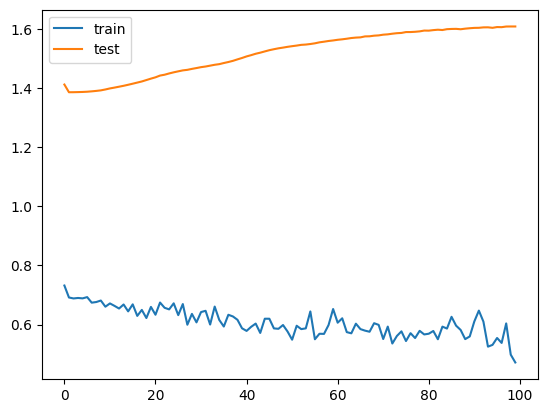

In [70]:
plt.plot(train_set_loss_per_epoch, label='train')
plt.plot(test_set_loss_per_epoch, label='test')
plt.legend()
plt.show()

## Guardar el modelo

Ya tenemos nuestro modelo entrenado, ahora queda lo mejor, mandarlo a producción y que la gente pueda usarlo, para ello tienes que exportar el state_dict y este se guardará en un archivo con todos los pesos aprendidos.

In [71]:
# Guardar solo los pesos
torch.save(model.state_dict(), "modelo_entrenado.pth")

# (opcional) Guardar también optimizador si quieres reanudar training cuando
# Este es muy largo y no quieres perder el proceso que llevas
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss,
}, "checkpoint.pth")

Ya tenemos todo lo que necesitamos para recrear chatGPT (bueno más o menos)

## Ahora si, hagamos chatGPT

Replicaremos el paper de 2017 que fue el que provocó la avalancha de la IA
https://arxiv.org/pdf/1706.03762

## La atención es todo lo que necesitas
Lo más importante que incluye este paper y esta nueva arquitectura es la atención

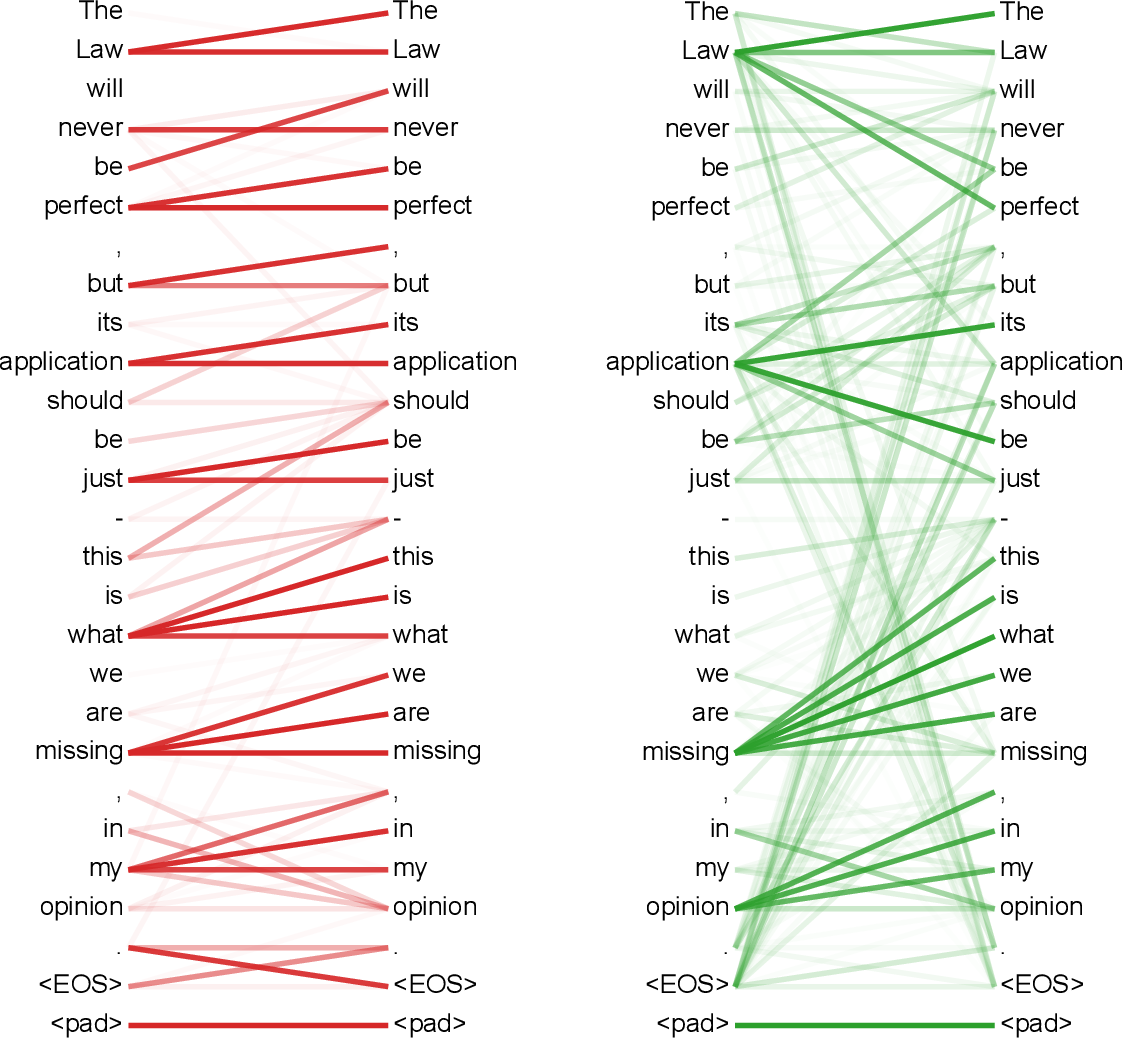

In [100]:
from transformer import Encoder, Decoder
class Transformer(nn.Module):
    def __init__(
            self,
            d_model: int = 256,
            ffn_hidden: int = 1024,
            num_heads: int = 4,
            drop_prob: float = 0.1,
            num_layers: int = 6,
            max_sequence_length: int = 200,
            tgt_vocab_size: int = 10000,
            src_to_index: dict | None = None,
            tgt_to_index: dict | None = None,

        ):
        super().__init__()
        self.encoder = Encoder(d_model, ffn_hidden, num_heads, drop_prob, num_layers, max_sequence_length, src_to_index)
        self.decoder = Decoder(d_model, ffn_hidden, num_heads, drop_prob, num_layers, max_sequence_length, tgt_to_index)
        self.linear = nn.Linear(d_model, tgt_vocab_size)
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

    def forward(self,
                x,
                y,
                encoder_self_attention_mask=None,
                decoder_self_attention_mask=None,
                decoder_cross_attention_mask=None,
                ): # x, y are batch of sentences
        x = self.encoder(x, encoder_self_attention_mask)
        out = self.decoder(x, y, decoder_self_attention_mask, decoder_cross_attention_mask)

        out = self.linear(out) # batch_size x max_sequence_length x d_model -> batch_size x max_sequence_length x vocab_size
        return out

ModuleNotFoundError: No module named 'transformer'

In [74]:
import spacy
from collections import defaultdict
import json
from functools import reduce
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import tiktoken
import string
import os
# -------------------------------------------------------------------------Models for word tokens
languages_dict = {}
dir_path = Path('.')
data_path = dir_path / 'data.csv'
vocab_path = dir_path / 'vocab.json'
START_TOKEN = '<START>'
PADDING_TOKEN = '<PAD>'
END_TOKEN = '<END>'
UNKNOWN_TOKEN = '<UNK>'

special_tokens = [PADDING_TOKEN, START_TOKEN, END_TOKEN, UNKNOWN_TOKEN]


In [75]:
# Load your data
languages_df = pd.read_csv(data_path)

# Función built-in de python
punctuation = list(string.punctuation)
punctuation = pd.Series(punctuation)

# Eliminar signos de puntuación de las palabras
punctuation_pattern = r'[^\w\s]'
languages_df['english'] = languages_df['english'].replace(punctuation_pattern, '', regex=True)

unique_english_words = (
    languages_df["english"]
    .str
    .lower()
    .str
    .split(" ")
    .explode()
    .drop_duplicates()
)
unique_english_words = pd.concat([unique_english_words, punctuation], ignore_index=True)

languages_df['spanish'] = languages_df['spanish'].replace(punctuation_pattern, '', regex=True)
unique_spanish_words = (
    languages_df["spanish"]
    .str
    .lower()
    .str
    .split(" ")
    .explode()
    .drop_duplicates()
)
unique_spanish_words = pd.concat([unique_spanish_words, punctuation], ignore_index=True)

# Crear diccionarios de palabra -> numero
src_to_index = {word: idx for idx, word in enumerate(unique_spanish_words, start=len(special_tokens))}
tgt_to_index = {word: idx for idx, word in enumerate(unique_english_words, start=len(special_tokens))}


# Add special tokens (optional, reserved first indices)
special_tokens_dict = { key: index for index, key in enumerate(special_tokens)}
src_to_index = {**special_tokens_dict, **src_to_index}
tgt_to_index = {**special_tokens_dict, **tgt_to_index}

languages_df.head(), languages_df.shape


(  english spanish
 0      Go      Ve
 1      Go    Vete
 2      Go    Vaya
 3      Go  Váyase
 4      Hi    Hola,
 (118964, 2))

In [76]:
src_to_index, tgt_to_index

({'<PAD>': 0,
  '<START>': 1,
  '<END>': 2,
  '<UNK>': 3,
  've': 4,
  'vete': 5,
  'vaya': 6,
  'váyase': 7,
  'hola': 8,
  'corre': 9,
  'corred': 10,
  'quién': 11,
  'fuego': 12,
  'incendio': 13,
  'disparad': 14,
  'ayuda': 15,
  'socorro': 16,
  'auxilio': 17,
  'salta': 18,
  'salte': 19,
  'parad': 20,
  'para': 21,
  'pare': 22,
  'espera': 23,
  'esperen': 24,
  'continúa': 25,
  'continúe': 26,
  'corrí': 27,
  'corría': 28,
  'lo': 29,
  'intento': 30,
  'he': 31,
  'ganado': 32,
  'oh': 33,
  'no': 34,
  'tomátelo': 35,
  'con': 36,
  'soda': 37,
  'sonríe': 38,
  'al': 39,
  'ataque': 40,
  'atacad': 41,
  'levanta': 42,
  'ahora': 43,
  'mismo': 44,
  'tengo': 45,
  'pillas': 46,
  'entendiste': 47,
  'él': 48,
  'corrió': 49,
  'métete': 50,
  'adentro': 51,
  'abrázame': 52,
  'me': 53,
  'caí': 54,
  'yo': 55,
  'sé': 56,
  'salí': 57,
  'mentí': 58,
  'perdí': 59,
  'dimito': 60,
  'renuncié': 61,
  'estoy': 62,
  'trabajando': 63,
  'diecinueve': 64,
  'levantado':

In [77]:
unique_english_words.head(), unique_english_words.shape

(0      go
 1      hi
 2     run
 3     who
 4    fire
 dtype: object,
 (13643,))

In [78]:
unique_spanish_words.head(), unique_spanish_words.shape

(0        ve
 1      vete
 2      vaya
 3    váyase
 4      hola
 dtype: object,
 (26059,))

In [79]:
import re

def tokenize(sentences, vocab:dict, return_str: bool = False):
    words = [START_TOKEN, *re.findall(r"\w+|[^\w\s]", sentences.lower()), END_TOKEN]
    # mantiene palabras y signos como tokens
    tokens = [vocab.get(w, vocab["<UNK>"]) for w in words]


    if return_str:
        return " ".join(str(t) for t in tokens)
    return tokens


tokenize('Hola mundo, mi nnefnjuwombre es Ivan', src_to_index)

[1, 8, 1489, 26042, 600, 3, 339, 3, 2]

In [80]:
MAX_SEQUENCE_LENGTH = 60
VOCAB_SIZE = 10000

VOCAB = {}

VOCAB['english'] = tgt_to_index
VOCAB['spanish'] = src_to_index


# Process English and Spanish separately
if os.path.exists(vocab_path):
    try:
        with open(vocab_path, 'r') as file:
            VOCAB = json.load(file)
    except json.JSONDecodeError:
        print(f"Error decoding JSON from {vocab_path}. Creating new vocab file.")
        if len(VOCAB.keys()) == 0:
          VOCAB['english'] = tgt_to_index
          VOCAB['spanish'] = src_to_index

        # Save the vocabulary to a JSON file
        with open(vocab_path, 'w') as file:
            json.dump(VOCAB, file, ensure_ascii=False, indent=4)
else:

  if len(VOCAB.keys()) == 0:
      VOCAB['english'] = tgt_to_index
      VOCAB['spanish'] = src_to_index

  # Save the vocabulary to a JSON file
  with open(vocab_path, 'w') as file:
      json.dump(VOCAB, file, ensure_ascii=False, indent=4)




# Working for single words
def is_valid_tokens(sentence, vocab, unk_idx):
  sentence = tokenize(sentence, vocab)

  for token in sentence:

    if token == unk_idx:
      return False
  return True


def length_is_valid(sentence, max_sequence_length):
  return len(list(sentence)) < (max_sequence_length - 1) # need to re-add the end token so leaving 1 space



In [81]:
print(is_valid_tokens('Hola, se iban', VOCAB['spanish'], src_to_index['<UNK>']))
print(is_valid_tokens('Hola, se iban', VOCAB['english'], src_to_index['<UNK>']))
print(is_valid_tokens('Hola, se Ivan', VOCAB['spanish'], tgt_to_index['<UNK>']))
print(length_is_valid('Hola, se iban ', MAX_SEQUENCE_LENGTH))
print(length_is_valid(' '* 100, MAX_SEQUENCE_LENGTH))

True
False
False
True
False


In [82]:
NEG_INFTY = -1e9

def create_masks(encoder_input: torch.Tensor, decoder_input: torch.Tensor, pad_idx: int = 0):
    """
    encoder_input: (batch, enc_len)
    decoder_input: (batch, dec_len)
    pad_idx: index used for <PAD> tokens
    """
    batch_size, enc_len = encoder_input.size()
    _, dec_len = decoder_input.size()

    NEG_INFTY = -1e9  # Or use torch.finfo().min

    # ---- Encoder padding mask ----
    enc_padding_mask = (encoder_input == pad_idx)  # (batch, enc_len)
    enc_self_mask = enc_padding_mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, enc_len)
    enc_self_mask = enc_self_mask.expand(batch_size, num_heads, enc_len, enc_len)
    enc_self_mask = torch.where(enc_self_mask, NEG_INFTY, 0).to(device)

    # ---- Decoder look-ahead mask ----
    look_ahead_mask = torch.triu(torch.ones((dec_len, dec_len), dtype=torch.bool), diagonal=1)
    look_ahead_mask = look_ahead_mask.to(device)
    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(0)  # (1, 1, dec_len, dec_len)
    look_ahead_mask = look_ahead_mask.expand(batch_size, num_heads, dec_len, dec_len)

    # ---- Decoder padding mask ----
    dec_padding_mask = (decoder_input == pad_idx)  # (batch, dec_len)
    dec_padding_mask = dec_padding_mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, dec_len)
    dec_padding_mask = dec_padding_mask.expand(batch_size, num_heads, dec_len, dec_len)

    # ---- Combine look-ahead + padding ----
    dec_self_mask = look_ahead_mask | dec_padding_mask
    dec_self_mask = torch.where(dec_self_mask, NEG_INFTY, 0).to(device)

    # ---- Decoder cross-attention mask ----
    # Mask encoder positions that are PAD during cross-attention
    cross_mask = (encoder_input == pad_idx)  # (batch, enc_len)
    cross_mask = cross_mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, enc_len)
    cross_mask = cross_mask.expand(batch_size, num_heads, dec_len, enc_len)
    cross_mask = torch.where(cross_mask, NEG_INFTY, 0).to(device)

    return enc_self_mask, dec_self_mask, cross_mask


In [83]:
def pad_sequence(sequences, max_length, padding_value=0):
    padded_sequences = [seq for seq in sequences]
    for i in range(max_length - len(sequences)):
      padded_sequences.append(padding_value)
    return padded_sequences
pad_sequence([1,2,2,3], 10, 0)

[1, 2, 2, 3, 0, 0, 0, 0, 0, 0]

In [84]:
# TRANSFORMER MODEL
d_model = 512
batch_size = 30
ffn_hidden = 2048
num_heads = 8
drop_prob = 0.1
num_layers = 1

BATCH_SIZE = 50

en_vocab_size = len(VOCAB['english'])

transformer = Transformer(d_model,
                          ffn_hidden,
                          num_heads,
                          drop_prob,
                          num_layers,
                          MAX_SEQUENCE_LENGTH,
                          en_vocab_size,
                          VOCAB['spanish'],
                          VOCAB['english']
                          ).to(device)

In [85]:
# Tokenize sentences
tokenized_spanish = torch.tensor([pad_sequence(tokenize(sentence, VOCAB['spanish']), MAX_SEQUENCE_LENGTH, VOCAB['spanish'][PADDING_TOKEN]) for sentence in languages_df['spanish']])
tokenized_english = torch.tensor([pad_sequence(tokenize(sentence, VOCAB['english']), MAX_SEQUENCE_LENGTH, VOCAB['english'][PADDING_TOKEN]) for sentence in languages_df['english']])
print(tokenized_spanish.shape)
train_loader = DataLoader(
    list(zip(tokenized_spanish, tokenized_english)),
    batch_size=BATCH_SIZE,
    shuffle=True
)
X, Y = next(iter(train_loader))
print(X.shape, Y.shape)

print(len(tokenized_spanish), len(tokenized_english))
tokenized_english[-1]

torch.Size([118964, 60])
torch.Size([50, 60]) torch.Size([50, 60])
118964 118964


tensor([    1,  1707,    91,   424,   240,  1508,   260,   109,  6179,  6180,
           91,   411,    52,  4368,   240,  1740,  2643,   727,  2117,  5007,
          227,   800,   227,    31,   727,  2117,    44,   242, 10686,  5071,
         1740,   727,  2117,  7028,   227,   800,   227,  3912,   202,   140,
          472,    28,  4179,   800,   475,   727, 13613, 13614,     2,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])

In [86]:

loss_fn = nn.CrossEntropyLoss(ignore_index=src_to_index[PADDING_TOKEN],
                                reduction='none')

# When computing the loss, we are ignoring cases when the label is the padding token
for params in transformer.parameters():
    if params.dim() > 1:
        nn.init.xavier_uniform_(params)

optim = torch.optim.Adam(transformer.parameters(), lr=1e-4)

## Train Loop

In [87]:
from tqdm import tqdm

losses = []
num_epochs = 20

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    batch_loss_sum = 0.0
    num_batches = 0

    pbar = tqdm(train_loader, total=len(train_loader), desc="Batches")

    for X, Y in pbar:
        X, Y = X.to(device), Y.to(device)
        transformer.train()

        encoder_self_attention_mask, decoder_self_attention_mask, decoder_cross_attention_mask = create_masks(X, Y, pad_idx=0)
        encoder_self_attention_mask = encoder_self_attention_mask.to(device)
        decoder_self_attention_mask = decoder_self_attention_mask.to(device)
        decoder_cross_attention_mask = decoder_cross_attention_mask.to(device)

        optim.zero_grad()
        predictions = transformer(
            X, Y,
            encoder_self_attention_mask,
            decoder_self_attention_mask,
            decoder_cross_attention_mask
        )

        loss = loss_fn(
            predictions.view(-1, en_vocab_size).to(device),
            Y.view(-1)
        )
        valid_indices = (Y.view(-1) != VOCAB['english'][PADDING_TOKEN])
        loss = (loss * valid_indices).sum() / valid_indices.sum()

        loss.backward()
        optim.step()

        loss_value = loss.item()
        losses.append(loss_value)
        batch_loss_sum += loss_value
        num_batches += 1

        avg_loss = batch_loss_sum / num_batches
        pbar.set_postfix(loss=f"{avg_loss:.4f}", refresh=True)


Epoch 1/20


Batches:   0%|          | 2/2380 [00:13<4:23:52,  6.66s/it, loss=9.4792]


KeyboardInterrupt: 

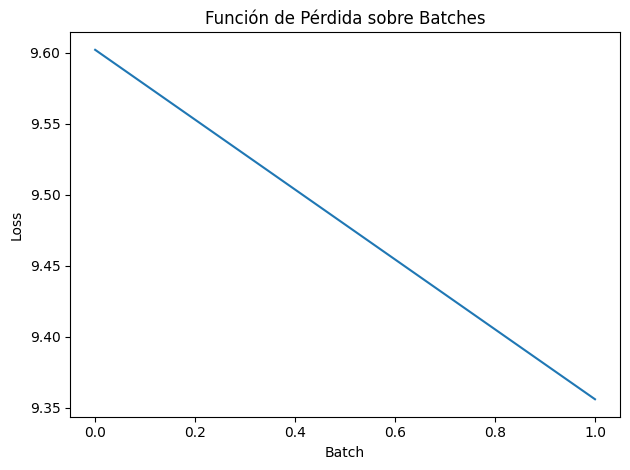

In [88]:
plt.plot(losses, label='Pérdida en entrenamiento')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Función de Pérdida sobre Batches')
plt.tight_layout()
plt.show()

In [89]:
# Guardar solo los pesos
torch.save(transformer.state_dict(), "transformer_entrenado.pth")

# (opcional) Guardar también optimizador si quieres reanudar training cuando
# Este es muy largo y no quieres perder el proceso que llevas
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss,
}, "checkpoint.pth")

## Función para traducir

Esta es la parte final del taller, ahora tienes una función que te permite traducir cualquier input en español que le entregues a inglés, prueba ajustando los hiperparámetros para que veas como cambian los resultados.

In [98]:
def translate(spanish_sentence, max_len=MAX_SEQUENCE_LENGTH):
    transformer.eval()
    index_to_english = {v: k for k, v in VOCAB['english'].items()}

    # Tokenizar y paddear input
    src = tokenize(spanish_sentence, VOCAB['spanish'])
    src = pad_sequence(src, max_len, VOCAB['spanish'][PADDING_TOKEN])
    src = torch.tensor(src).unsqueeze(0).to(device)  # (1, src_len)

    # Inicializamos el decoder con <START> + PADs
    tgt_sentence = [VOCAB['english'][START_TOKEN]] + \
                   [VOCAB['english'][PADDING_TOKEN]] * (max_len - 1)
    tgt_tensor = torch.tensor(tgt_sentence).unsqueeze(0).to(device)  # (1, max_len)

    # Crear máscaras
    enc_mask, dec_mask, cross_mask = create_masks(
        src, tgt_tensor, pad_idx=VOCAB['english'][PADDING_TOKEN]
    )

    with torch.no_grad():
        logits = transformer(
            src, tgt_tensor,
            enc_mask.to(device),
            dec_mask.to(device),
            cross_mask.to(device)
        )

    # Tomamos el token más probable en cada posición (sin argmax por now)
    probs = F.softmax(logits, dim=-1)
    predicted_indices = torch.argmax(probs, dim=-1).squeeze().tolist()

    # Parar en <END>
    output_tokens = []
    for idx in predicted_indices[1:]:  # omitimos <START>
        if idx == VOCAB['english'][END_TOKEN]:
            break
        output_tokens.append(index_to_english[idx])

    return " ".join(output_tokens)


Prueba con otras palabras

In [99]:
translation = translate("Que hay para hacer?")
print(translation)

tensor([[[5.1280e-05, 3.4421e-04, 2.6831e-04,  ..., 4.4955e-05,
          6.6959e-05, 5.6766e-05],
         [5.0489e-05, 3.4885e-04, 2.7183e-04,  ..., 4.3812e-05,
          7.1312e-05, 5.8064e-05],
         [4.7786e-05, 3.3989e-04, 2.9170e-04,  ..., 4.2870e-05,
          7.5901e-05, 5.9030e-05],
         ...,
         [4.4581e-05, 3.1560e-04, 3.5241e-04,  ..., 5.2119e-05,
          6.2914e-05, 8.6112e-05],
         [4.5523e-05, 3.3154e-04, 3.5536e-04,  ..., 5.5187e-05,
          6.3824e-05, 8.6647e-05],
         [4.7653e-05, 3.2279e-04, 3.6806e-04,  ..., 5.5599e-05,
          6.1879e-05, 8.5101e-05]]])
<START> <START>
